Propriedades do ar obtidas pelo CoolProp:
h_ga calculado: 2.051 W/m²K
h_gam calculado: 3506.849 W/m²K
T_a interno mantido constante em: 323.15 K


Operator `Kernel` ran in 0.17 s


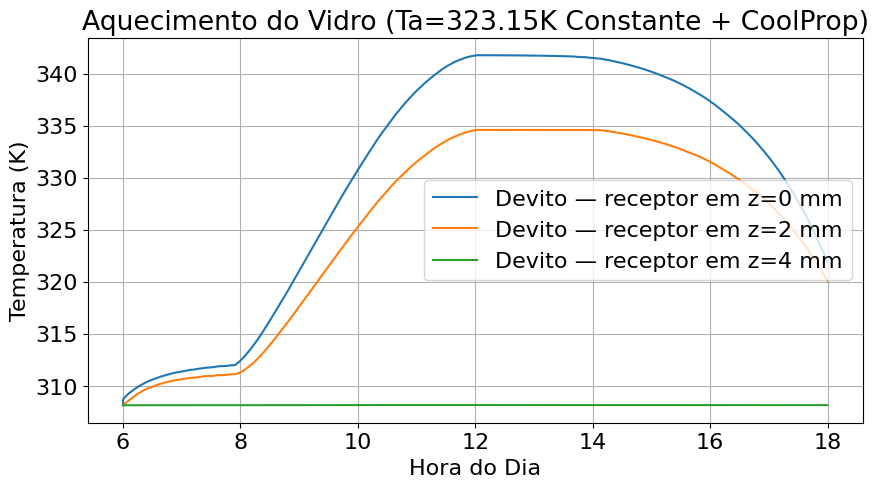

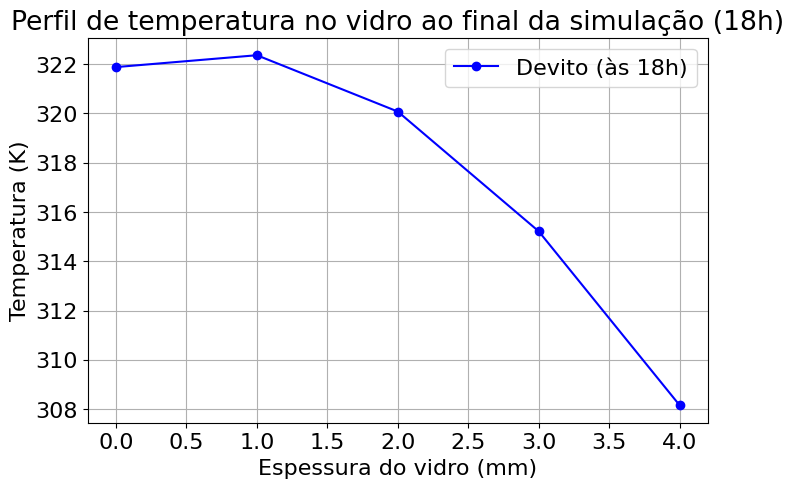

In [41]:
import numpy as np
from devito import *
import matplotlib.pyplot as plt
import math
from examples.seismic.source import Receiver, TimeAxis
import CoolProp.CoolProp as CP

# ============================================================================
# BLOCO DA RADIAÇÃO 
# ============================================================================
def deg2rad(x): return x * math.pi / 180.0
def rad2deg(x): return x * 180.0 / math.pi

def SolarDeclination(day_of_year):
    deg = 23.45 * math.sin(deg2rad(360.0 * (284 + day_of_year) / 365.0))
    return deg2rad(deg)

def hour_angle(hora_decimal):
    return deg2rad((hora_decimal - 12.0) * 15.0)

def sin_solar_altitude(latitude_deg, decl_rad, hour_ang_rad):
    i = deg2rad(latitude_deg)
    return math.cos(i) * math.cos(hour_ang_rad) * math.cos(decl_rad) + math.sin(i) * math.sin(decl_rad)

def direct_radiation(Ic, B, sinb):
    if sinb <= 0.0: return 0.0
    return Ic * math.exp(-B / sinb)

def FSS(tilt_deg):
    S = deg2rad(tilt_deg)
    return (1.0 + math.cos(S)) / 2.0

def diffuse_radiation(IDN, tilt_deg):
    C = 0.135
    return C * IDN * FSS(tilt_deg)

def Fsg(tilt_deg):
    S = deg2rad(tilt_deg)
    return (1.0 - math.cos(S)) / 2.0

def reflected_radiation(IDN, Idq, tilt_deg):
    krq = 0.2
    return (IDN + Idq) * krq * Fsg(tilt_deg)

def cos_solar_azimuth(latitude_deg, decl_rad, sinb):
    i = deg2rad(latitude_deg)
    numerador = (sinb - math.sin(i) * math.sin(decl_rad))
    denominador = math.cos(i) * math.cos(decl_rad)
    if abs(denominador) < 1e-8: return 1.0
    cosf = numerador / denominador
    return max(-1.0, min(1.0, cosf))

def cos_incidence_full(latitude_deg, decl_rad, tilt_deg, hour_ang_rad, cosf):
    i = deg2rad(latitude_deg)
    S = deg2rad(tilt_deg)
    sinf = math.sqrt(max(0.0, 1.0 - cosf**2))
    term1 = math.sin(decl_rad) * math.sin(i) * math.cos(S)
    term2 = -math.sin(decl_rad) * math.cos(i) * math.sin(S) * cosf
    term3 = math.cos(decl_rad) * math.cos(i) * math.cos(S) * math.cos(hour_ang_rad)
    term4 = math.cos(decl_rad) * math.sin(i) * math.sin(S) * cosf * math.cos(hour_ang_rad)
    term5 = math.cos(decl_rad) * math.sin(S) * sinf * math.sin(hour_ang_rad)
    return term1 + term2 + term3 + term4 + term5

def total_radiation(IDN, Idq, Irq, cosq):
    if cosq < 0: cosq = 0.0
    return IDN * cosq + Idq + Irq

def compute_It_series(time_seconds, latitude_deg=32, tilt_deg=37, day_of_year=200, Ic=1357.0, B=0.21):
    times = np.asarray(time_seconds)
    hours = (times / 3600.0)  
    decl = SolarDeclination(day_of_year)
    It_series = np.zeros_like(hours)
    for idx, h in enumerate(hours):
        Hr = hour_angle(h)
        sinb = sin_solar_altitude(latitude_deg, decl, Hr)
        if sinb <= 0:
            It_series[idx] = 0.0
            continue
        IDN = direct_radiation(Ic, B, sinb)
        Idq = diffuse_radiation(IDN, tilt_deg)
        Irq = reflected_radiation(IDN, Idq, tilt_deg)
        cosf = cos_solar_azimuth(latitude_deg, decl, sinb)
        cosq = cos_incidence_full(latitude_deg, decl, tilt_deg, Hr, cosf)
        It = total_radiation(IDN, Idq, Irq, cosq)
        It_series[idx] = It
    return It_series
# ============================================================================


# Coeficientes do vidro
k_g     = 5.9/1000     # Condutividade Térmica do Vidro (W/m·K)
C_g     = 753     # Calor específico do vidro (J/kg·K)
ro_g    = 2466    # Densidade do Vidro (kg/m³)
delta_g = 4e-03    # Espessura do vidro (m) = 4mm
L       = 2       # Comprimento do coletor (m) — mantido para definir o grid
alpha_g = 0.1     # Absortividade optica do vidro (?)

# Grade de tempo simplificada
# Começa do segundo e termina no 30
t0 = 6 * 3600
tn = 18 * 3600
dt0 = 0.1 
nt = int((tn - t0) / dt0)
time_range = TimeAxis(start=t0, stop=tn, num=nt+1)

# Discretização da malha
# nx=30
# nz=5: 5 pontos ao longo da espessura do vidro (z = 0, 1, 2, 3, 4 mm)
nx = 30
nz = 5

class Interior(SubDomain):
    name = 'interior'
    def define(self, dimensions):
        x, z = dimensions
        return {x: x, z: ('middle', 1, 1)}

class Fundo(SubDomain):
    name = 'fundo'
    def define(self, dimensions):
        x, z = dimensions
        return {x: x, z: ('right', 1)}

# Grid 2D
x = SpaceDimension(name='x')
z = SpaceDimension(name='z')
grid = Grid(shape=(nx, nz), extent=(L, delta_g), dimensions=(x, z))

time = grid.time_dim    # guarda linha do tempo contínua ao invés de 2 instantes de tempo

dx, dz = grid.spacing
interior = Interior(grid=grid)
fundo = Fundo(grid=grid)

# Temperatura do vidro
TemperaturaVidro = TimeFunction(name='T_g',
                                grid=grid,
                                dimensions=(grid.time_dim, x, z),
                                save=nt+1, shape=(nt+1, nx, nz),
                                space_order=2)

# Condição inicial: 308.15 K (35°C) pra ser uniforme em todo o vidro
TemperaturaVidro.data_with_halo[:] = 308.15

# ----------------------------------------------------------------------------------------------------------------------------------------
segundos_do_dia = np.linspace(t0, tn, nt+1)    # Cria um vetor contendo todos os instantes de tempo discretizados (de t0 até tn)
It_series = compute_It_series(segundos_do_dia)     # Calcula a radiação solar (W/m²) p cada segundo gerado acima. O retorno é um array normal do Python

I_t_devito = Function(name='I_t', dimensions=(time,), shape=(nt+1,))    # devito trabalha de forma simbólica em C e não aceita arrays do Python direto na equação.
                                                                        # Então, declaramos uma função temporal oficial do Devito (dimensão 'time') para alocar memória

I_t_devito.data[:] = It_series    # Injeta os valores do array numérico (It_series) para dentro da estrutura de dados do Devito:

termo_radiacao = (I_t_devito * alpha_g) / (ro_g * C_g * delta_g)    # Termo fonte montado

# ----------------------------------------------------------------------------------------------------------------------------------------

eq11 = Eq(TemperaturaVidro.dt, ((k_g / (C_g * ro_g)) * TemperaturaVidro.dz2) + termo_radiacao)

eq_1 = Eq(TemperaturaVidro.forward, solve(eq11, TemperaturaVidro.forward), subdomain=interior)

# ----------------------------------------------------------------------------------------------------------------------------------------


# CONDIÇÕES DE CONTORNO COM COOLPROP ==========================

# OBS: a T_a vai mudar depois, e ser variável
T_a_pico = 345.15 
T_a_series = 308.15 + (It_series / np.max(It_series)) * (T_a_pico - 308.15)

T_a_devito = Function(name='T_a_dyn', dimensions=(time,), shape=(nt+1,))
T_a_devito.data[:] = T_a_series


#T_a = 323.15     # MANTIDO: 50°C de ar quente constante dentro do secador
T_am = 308.15    # MANTIDO: 35°C de ar ambiente constante fora do secador (vento)

# Adicionado os parâmetros reais para o cálculo da convecção
P_atm = 101325 
VelocidadeAr = 1.0 # m/s
ro_a = 1.09        # Densidade do ar   
a_duto = 0.1       # Altura do duto (m)
L_coletor = 2.0    # Comprimento do coletor (m)

# temperatura de referência para propriedades do ar
T_ref = 308.15     

# Puxando propriedades do Coolprop
viscosidadeDinamica = CP.PropsSI("V", "T", T_ref, "P", P_atm, "Air")
calorEspecifico = CP.PropsSI("CPMASS", "T", T_ref, "P", P_atm, "Air")
condutividadeTermica = CP.PropsSI("CONDUCTIVITY", "T", T_ref, "P", P_atm, "Air")

Re = ro_a * VelocidadeAr * L_coletor / viscosidadeDinamica
Pr = calorEspecifico * viscosidadeDinamica / condutividadeTermica

# Calculando h_ga (Convecção interna) usando eq 14 do artigo
if Re * Pr * (a_duto / L_coletor) > 70:
    Nu = 7.6
else:
    Nu = 1.85 * (Re * Pr * a_duto / L_coletor)**(1/3)
h_ga = (Nu * condutividadeTermica / a_duto )

# Calculando h_gam (Convecção externa) usando eq 19 do artigo
Nu_gam = 0.86 * (Re**0.5) * (Pr**(1/3))
h_gam = (Nu_gam * condutividadeTermica / L_coletor)*1000

# pra ver dados no terminal:
print("==================================================")
print(f"Propriedades do ar obtidas pelo CoolProp:")
print(f"h_ga calculado: {h_ga:.3f} W/m²K")
print(f"h_gam calculado: {h_gam:.3f} W/m²K")
print(f"T_a interno mantido constante em: {T_a} K")
print("==================================================")

# Equação 17: O topo (face interna, z=0) usando T_a fixo e h_ga do CoolProp
eq_topo = Eq(TemperaturaVidro[time+1, x, 0], 
             (k_g * TemperaturaVidro[time, x, 1] + h_ga * dz * T_a_devito) / (k_g + h_ga * dz))

# Equação 18: O fundo (face externa, z=4mm) usando T_am fixo e h_gam do CoolProp
eq_fundo = Eq(TemperaturaVidro[time+1, x, nz-1], 
             (k_g * TemperaturaVidro[time, x, nz-2] + h_gam * dz * T_am) / (k_g + h_gam * dz))

#T_fria = 35+273.15

#eq_fundo = Eq(TemperaturaVidro, T_fria,   subdomain=fundo)
# ========================================================================================

nrec = 3
rec_T = Receiver(name="rec_T", grid=grid, npoint=nrec, time_range=time_range)
rec_T.coordinates.data[:, 0] = [L/2,L/2,L/2]     
rec_T.coordinates.data[:, 1] = [0,delta_g/2,delta_g]
rec_term = rec_T.interpolate(expr=TemperaturaVidro)

op = Operator([eq_topo, eq_1, eq_fundo] + rec_term)

op(dt=dt0, time_M=nt-1)

horas_eixo_x = segundos_do_dia / 3600.0

plt.figure(figsize=(10, 5))
plt.plot(horas_eixo_x[:-1], rec_T.data[:-1, 0], label="Devito — receptor em z=0 mm")
plt.plot(horas_eixo_x[:-1], rec_T.data[:-1, 1], label="Devito — receptor em z=2 mm")
plt.plot(horas_eixo_x[:-1], rec_T.data[:-1, 2], label="Devito — receptor em z=4 mm")
plt.xlabel("Hora do Dia")
plt.ylabel("Temperatura (K)")
plt.title(f"Aquecimento do Vidro (Ta={T_a}K Constante + CoolProp)")
plt.ticklabel_format(useOffset=False, style='plain') 
plt.legend()
plt.grid()
plt.show()
z_mm       = np.linspace(0, delta_g * 1000, nz)          
T_devito   = TemperaturaVidro.data[-1, int(nx/2), :]     

plt.figure(figsize=(8, 5))
plt.plot(z_mm, T_devito, 'bo-', label="Devito (às 18h)")
plt.xlabel("Espessura do vidro (mm)")
plt.ylabel("Temperatura (K)")
plt.title("Perfil de temperatura no vidro ao final da simulação (18h)")
plt.ticklabel_format(useOffset=False, style='plain')
plt.legend()
plt.grid()
plt.show()